# Character Identification CNN Model

### Import Modules

This notebook uses PyTorch for the processing.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
import cv2
import os
import random

from torchvision.transforms import v2
from utils import is_char_correct_with_allowance

In [2]:
train_data_dir = "./chars_train_data"
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

### Object Classes
Set up the mapping of each character label to the label ID

In [3]:
char_classes = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "a": 10,
    "b": 11,
    "c": 12,
    "d": 13,
    "e": 14,
    "f": 15,
    "g": 16,
    "h": 17,
    "i": 18,
    "j": 19,
    "k": 20,
    "l": 21,
    "m": 22,
    "n": 23,
    "o": 24,
    "p": 25,
    "q": 26,
    "r": 27,
    "s": 28,
    "t": 29,
    "u": 30,
    "v": 31,
    "w": 32,
    "x": 33,
    "y": 34,
    "z": 35,
}
num_classes = len(char_classes)
print(num_classes)

36



### Setting up the Dataset and Train + Validation Dataloaders (with augmentation)

For more information about creating custom dataset and using dataloader, check out [this tutorial](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html).


In [4]:
import os, random, cv2, torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

validation_set_fraction = 0.1
seed = 42  # for reproducibility

class CharDataset(Dataset):
    def __init__(self, data_dir="", is_train=True):
        self.data_dir = data_dir
        self.is_train = is_train

        # --- Collect all PNG files ---
        self.image_files = [f for f in os.listdir(data_dir) if f.lower().endswith('.png')]
        if len(self.image_files) == 0:
            raise FileNotFoundError(f"No .png files found in {data_dir}")

        # Extract labels
        self.labels = [f.split('_')[0] for f in self.image_files]

        # --- Train/val split ---
        combined = list(zip(self.image_files, self.labels))
        random.seed(seed)
        random.shuffle(combined)

        split_idx = int(len(combined) * (1 - validation_set_fraction))
        if self.is_train:
            subset = combined[:split_idx]
        else:
            subset = combined[split_idx:]

        self.image_files, self.labels = zip(*subset)
        self.image_files, self.labels = list(self.image_files), list(self.labels)

        # --- Define transforms ---
        if self.is_train:
            self.transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.RandomAffine(
                    degrees=20,
                    shear=(-10, 15, -15, 15),
                    fill=(0,)
                ),
                transforms.ToTensor(),
            ])
        else:
            self.transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.ToTensor()
            ])
        
    def __len__(self):
        return len(self.image_files)
        
    def __getitem__(self, index):
        fname = self.image_files[index]
        label_str = self.labels[index]
        label_idx = char_classes[label_str]

        img_path = os.path.join(self.data_dir, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Cannot read image {img_path}")

        # Ensure correct size
        if img.shape[0] != 42 or img.shape[1] != 42:
            img = cv2.resize(img, (42, 42), interpolation=cv2.INTER_LINEAR)

        img = self.transform(img)

        return fname, img, label_idx


# --- Create datasets ---
train_dataset = CharDataset(data_dir=train_data_dir, is_train=True)
val_dataset = CharDataset(data_dir=train_data_dir, is_train=False)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

### Inspect and visualize your data

It is recommended to inspect some samples of your data through visualization

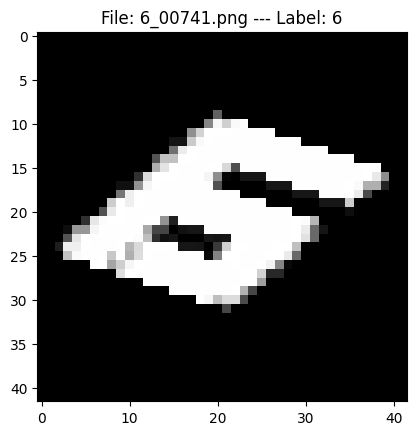

In [5]:
img_id, X_transformed, y = train_dataset[0]

plt.imshow(X_transformed[0], cmap='gray')
plt.title(f'File: {img_id} --- Label: {y}')
plt.show()


### Setting up the GPU


In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0



# Setting up your neural network model

As mentioned in the Getting Started section, you should check out this tutorial. Although not covered in lectures, you should consider learning and using these:

- Convolutional neural network layers ([``torch.nn.Conv2D``](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html))
- Maxpool layers ([``torch.nn.MaxPool2d``](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html))
- Adam optimizer ([``torch.nn.Adam``](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html))
- [Pre-trained models](https://pytorch.org/vision/stable/models.html)
- [Loss functions](https://pytorch.org/docs/stable/nn.html#loss-functions)



In [7]:
import torch.nn as nn
import torch.nn.functional as F

# Add your Neural Network here (if using NN)

class Model(nn.Module):
    def _get_conv_output(self, shape):
        """Pass a dummy input to conv layers to compute flatten size"""
        with torch.no_grad():
            x = torch.zeros(1, *shape)
            x = self.features(x)
            n_features = x.numel()  # total features for nn.Linear
        return n_features
    
    def __init__(self, input_shape=(1, 42, 42)):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.05),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.15),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )

        # --- Automatically compute flattened feature size ---
        self._to_linear = self._get_conv_output(input_shape)
        
        self.classifier = nn.Sequential(
            nn.Linear(self._to_linear, 256),  # adapt based on your input size
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

net = Model()
net.to(device)

def count_params(net, trainable=False):
    if trainable:
        count = sum(p.numel() for p in net.parameters() if p.requires_grad)
    else:
        count = sum(p.numel() for p in net.parameters())
    return count

print(F'Network has {count_params(net, trainable=False)} parameters in total')
print(F'Network has {count_params(net, trainable=True)} trainable parameters in total')

Network has 968196 parameters in total
Network has 968196 trainable parameters in total


# Training the Model

### Early stopping mechanism
Do not continue training if validation loss has not decreased for n epochs (prevents overfitting)

Mechanism referenced from: https://medium.com/biased-algorithms/a-practical-guide-to-implementing-early-stopping-in-pytorch-for-model-training-99a7cbd46e9d

In [8]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        """
        Stops training if val_loss doesn't improve after `patience` epochs.
        delta: minimum change to qualify as an improvement
        verbose: whether to print messages
        """
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.epochs_without_improvement = 0
        self.stop_training = False
        self.best_model_state = None
    
    def check_early_stopping(self, val_loss, model):
        """
        Call this at the end of each epoch.
        model: the network whose weights we want to save
        """
        if self.best_loss is None or val_loss < (self.best_loss - self.delta):
            self.best_loss = val_loss
            self.epochs_without_improvement = 0
            # Save a copy of the model weights
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"Validation loss improved to {val_loss:.4f}. Saving model weights.")
        else:
            self.epochs_without_improvement += 1
            if self.epochs_without_improvement >= self.patience:
                self.stop_training = True
                print("Stopping early as no validation loss improvement has been observed.")
    
    def load_best_weights(self, model, device='cpu'):
        """
        Restore the model to the best validation loss weights
        """
        if self.best_model_state is not None:
            model.load_state_dict({k: v.to(device) for k, v in self.best_model_state.items()})
            print("Model weights restored to best validation loss.")

# Initialize early stopping class
early_stopping = EarlyStopping(patience=15, delta=0)

### Training

Epoch 1/300: 100%|███████████████████████████████████████████████████████████████████| 624/624 [00:30<00:00, 20.64it/s]


Epoch [1/300] - Train Loss: 2.0803 - Val Loss: 1.2074
Validation loss improved to 1.2074. Saving model weights.


Epoch 2/300: 100%|███████████████████████████████████████████████████████████████████| 624/624 [00:28<00:00, 21.69it/s]


Epoch [2/300] - Train Loss: 1.4552 - Val Loss: 1.0088
Validation loss improved to 1.0088. Saving model weights.


Epoch 3/300: 100%|███████████████████████████████████████████████████████████████████| 624/624 [00:29<00:00, 21.30it/s]


...

Epoch [182/300] - Train Loss: 0.5454 - Val Loss: 0.5104


Epoch 183/300: 100%|█████████████████████████████████████████████████████████████████| 624/624 [00:25<00:00, 24.41it/s]


Epoch [183/300] - Train Loss: 0.5433 - Val Loss: 0.5105


Epoch 184/300: 100%|█████████████████████████████████████████████████████████████████| 624/624 [00:26<00:00, 23.83it/s]


Epoch [184/300] - Train Loss: 0.5429 - Val Loss: 0.5107
Stopping early as no validation loss improvement has been observed.
Early stopping at epoch 184
Model weights restored to best validation loss.


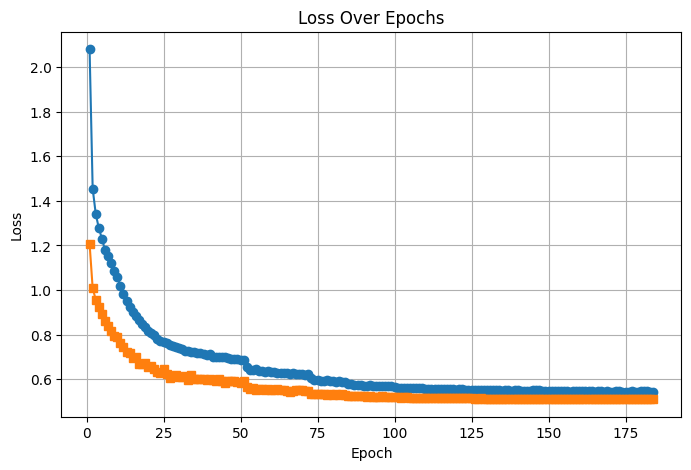

In [9]:
from tqdm import tqdm # for a progress bar

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.Adam(net.parameters(), weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5,
)
num_epochs = 300

epoch_train_losses = []  # store loss for each epoch
epoch_val_losses = []

for epoch in range(num_epochs):
    net.train()  # set model to training mode
    running_loss = 0.0 
    # Running loss sums the loss values for each mini-batch, to later compute the average loss per epoch

    # Training
    for img_id, X_transformed, y in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        X_transformed, y = X_transformed.to(device, non_blocking=True), y.to(device, non_blocking=True)

        # Forward pass
        y_pred_logits = net(X_transformed)
        loss = criterion(y_pred_logits, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation
    val_loss = 0.0
    net.eval()
    with torch.no_grad():
        for img_id, X_transformed, y in val_dataloader:
            X_transformed, y = X_transformed.to(device, non_blocking=True), y.to(device, non_blocking=True)
            
             # Forward pass
            y_pred_logits = net(X_transformed)
            loss = criterion(y_pred_logits, y)
            
            val_loss += loss.item()

    avg_train_loss = running_loss / len(train_dataloader)
    avg_val_loss = val_loss / len(val_dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

    epoch_train_losses.append(avg_train_loss)
    epoch_val_losses.append(avg_val_loss)

    # Step the scheduler using validation loss
    scheduler.step(avg_val_loss)

    # Early stopping?
    early_stopping.check_early_stopping(avg_val_loss, net)
    if early_stopping.stop_training:
        print(f"Early stopping at epoch {epoch + 1}")
        early_stopping.load_best_weights(net, device=device) # Restore best weights
        break

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(epoch_train_losses) + 1), epoch_train_losses, marker='o', label='Train Loss')
plt.plot(range(1, len(epoch_val_losses) + 1), epoch_val_losses, marker='s', label='Validation Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Making predictions
Naive: Simply take the highest logit and take it as prediction.

### Inference on single sample

In [11]:
def predict_single_image_with_variants(net, img, char_classes, variants=True, show=True):
    """
    Predicts a single character image using multiple augmentations:
    - original
    - inverted color
    - rotated -30 degrees
    - rotated +30 degrees
    Returns the most confident prediction.
    """
        
    # Predict single image and give prediction + confidence
    def predict_variant(img_variant):
        # Resize if needed
        if img_variant.shape[0] != 42 or img_variant.shape[1] != 42:
            img_variant = cv2.resize(img_variant, (42, 42), interpolation=cv2.INTER_LINEAR)

        # Normalize and tensorize
        img_variant = img_variant.astype('float32') / 255.0
        img_variant = np.expand_dims(img_variant, axis=0)   # (1, 42, 42)
        img_tensor = torch.tensor(img_variant, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 1, 42, 42)

        # Predict logits and confidence
        net.eval()
        with torch.no_grad():
            output = net(img_tensor)
            probs = F.softmax(output, dim=1)
            confidence, predicted_class = torch.max(probs, dim=1)

        return predicted_class.item(), confidence.item()

    # If we do not want to use variants, just predict the original img
    if not variants:
        pred_idx, _ = predict_variant(img)
        # Map index to label
        inv_char_classes = {v: k for k, v in char_classes.items()}
        predicted_label = inv_char_classes[pred_idx]
        
        if show:
            plt.imshow(img, cmap='gray')
            plt.title(f"Pred: {predicted_label}")
        return predicted_label

    
    # --- Create variants ---
    variants = {
        "original": img,
        "inverted": 255 - img,
        "rot_-15": cv2.warpAffine(img, cv2.getRotationMatrix2D((img.shape[1]//2, img.shape[0]//2), -15, 1.0), (img.shape[1], img.shape[0])),
        "rot_+15": cv2.warpAffine(img, cv2.getRotationMatrix2D((img.shape[1]//2, img.shape[0]//2), 15, 1.0), (img.shape[1], img.shape[0])),
        "scale_80": cv2.warpAffine(img, cv2.getRotationMatrix2D((img.shape[1]//2, img.shape[0]//2), 0, 0.8), (img.shape[1], img.shape[0])),
    }

    # --- Evaluate each variant ---
    best_pred = None
    best_conf = -1
    best_key = None
    preds_conf = {}

    # --- Predict each variant ---
    for key, variant in variants.items():
        pred_idx, conf = predict_variant(variant)
        preds_conf[key] = (pred_idx, conf)
        if conf > best_conf:
            best_conf = conf
            best_pred = pred_idx
            best_key = key

    # Map index to label
    inv_char_classes = {v: k for k, v in char_classes.items()}
    predicted_label = inv_char_classes[best_pred]

    # --- Plot all variants side by side (if show = True) ---
    if show:
        print(f"Best prediction: {predicted_label} ({best_key}, conf={best_conf:.2f})")
        plt.figure(figsize=(12, 3))
        for i, (key, variant) in enumerate(variants.items()):
            pred_idx, conf = preds_conf[key]
            label = inv_char_classes[pred_idx]
            plt.subplot(1, len(variants), i + 1)
            plt.imshow(variant, cmap='gray')
            plt.title(f"{key}\nPred: {label}\nConf: {conf:.2f}")
            plt.axis('off')
        plt.show()

    return predicted_label

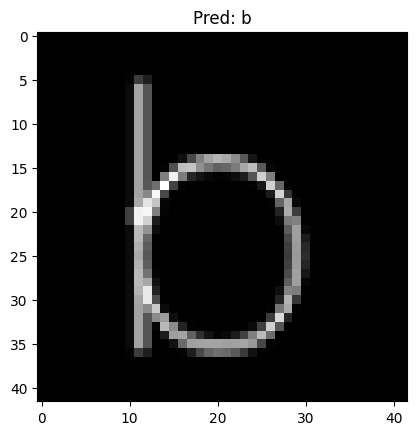

In [12]:
img_path = "./chars_train_data/b_00000.png"
# Load img
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"Cannot read image: {img_path}")

pred = predict_single_image_with_variants(net, img, char_classes, variants=False, show=True)

### Evaluate on Validation set

In [18]:
net.eval()  # set model to evaluation mode (disables dropout/batchnorm)
correct = 0
correct_with_allowance = 0
total = 0

for img_id, X_transformed, y in tqdm(val_dataloader):
    X_transformed = X_transformed.to(device) # Move to GPU
    y = y.to(device)

    # Loop over batch samples
    for i in range(X_transformed.size(0)):
        img_tensor = X_transformed[i].squeeze(0).cpu().numpy() * 255.0  # (42,42) grayscale
        true_idx = y[i].item()
        true_char = [k for k,v in char_classes.items() if v == true_idx][0]

        pred_char = predict_single_image_with_variants(net, img_tensor, char_classes, variants=False, show=False)

        # Update metrics
        if pred_char == true_char:
            correct += 1
        if is_char_correct_with_allowance(pred_char, true_char):
            correct_with_allowance += 1
        total += 1
        

accuracy = 100 * correct / total
accuracy_with_allowance = 100 * correct_with_allowance / total
print(f'Total: {total}')
print(f'Correct: {correct}')
print(f'Correct with Allowance: {correct_with_allowance}')
print(f'Accuracy on Validation Data: {accuracy:.2f}%')
print(f'Accuracy on Validation Data with Allowance: {accuracy_with_allowance:.2f}%')

100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:15<00:00,  4.39it/s]

Total: 4437
Correct: 4216
Correct with Allowance: 4364
Accuracy on Validation Data: 95.02%
Accuracy on Validation Data with Allowance: 98.35%


# Exporting the Model

In [16]:
torch.save(net, "char_classification_model.pth")
